# P2P Trading Hourly consumption and generation analysis
Assumptions and parameters</br>
Solar panel efficiency: 18%</br>
date: 01-01-2023 to 31-12-2023</br>

#### Generation by hour for a day in each season
This code takes random days from each season to visualize the energy consumption and generation patterns by hour 

C:\Users\medha\AppData\Local\Temp\ipykernel_16624\3708831365.py:39: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_timestamps = pd.date_range(start="2023-01-01", end="2023-12-31 23:00:00", freq="H")
C:\Users\medha\AppData\Local\Temp\ipykernel_16624\3708831365.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  postcode_expanded["solar_generation"].fillna(0, inplace=True)


Data after dropping postcodes with zero solar generation:
  Postcode6           timestamp  solar_panels  solar_generation
0    8031ER 2023-01-01 00:00:00             0               0.0
1    8031ER 2023-01-01 01:00:00             0               0.0
2    8031ER 2023-01-01 02:00:00             0               0.0
3    8031ER 2023-01-01 03:00:00             0               0.0
4    8031ER 2023-01-01 04:00:00             0               0.0


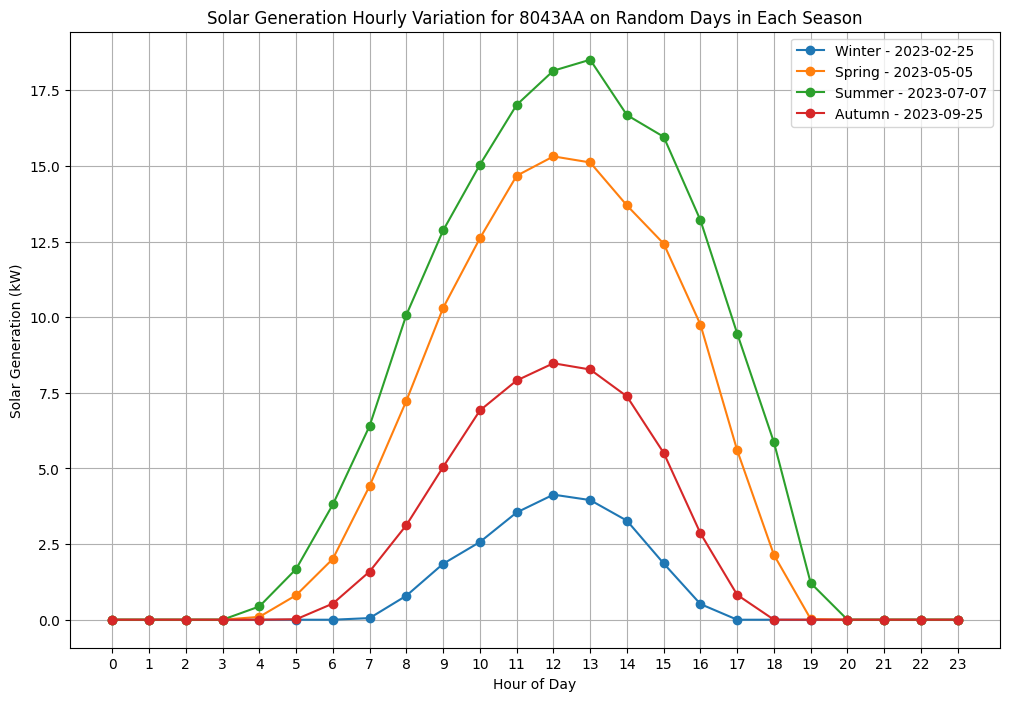

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import random

solar_df = pd.read_csv(r"C:\Users\medha\OneDrive - University of Twente\Documents\Q3\Datasets\SolarIrradiationPeaksandFalls.csv", skiprows=8, nrows=8760)  # Hourly solar irradiation
weather_df = pd.read_csv(r"C:\Users\medha\OneDrive - University of Twente\Documents\Q3\Datasets\HDD_CDD.csv")  # Daily weather data
postcode_gdf = gpd.read_file(r"C:\Users\medha\OneDrive - University of Twente\Documents\Q3\Datasets\postcode_solar_panels_building_count.shp")  # Postcode-level data

# Processing the solar data
solar_df['timestamp'] = pd.to_datetime(solar_df['time'], format='%Y%m%d:%H%M')
solar_df["hour"] = solar_df["timestamp"].dt.hour
solar_df["dayofweek"] = solar_df["timestamp"].dt.dayofweek
solar_df["month"] = solar_df["timestamp"].dt.month
solar_df["month"] = solar_df["month"].fillna(0).astype(int)

# Defining seasons
solar_df["season"] = np.select(
    [
        solar_df["month"].isin([12, 1, 2]),  # Winter
        solar_df["month"].isin([3, 4, 5]),   # Spring
        solar_df["month"].isin([6, 7, 8]),   # Summer
        solar_df["month"].isin([9, 10, 11])  # Autumn
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)
seasonal_irradiation = solar_df.groupby(["season", "hour"])["G(i)"].mean().reset_index()
postcode_gdf = postcode_gdf.dropna(subset=['Gemiddel_2'])
postcode_gdf["Gemiddel_2"] = pd.to_numeric(postcode_gdf["Gemiddel_2"], errors="coerce")
postcode_gdf["hourly_consumption"] = postcode_gdf["Gemiddel_2"] / 8760  # Convert yearly to hourly

# Add solar panel data and calculate solar generation
postcode_gdf['solar_panels'] = pd.to_numeric(postcode_gdf['Solar_Coun'], errors='coerce')
panel_efficiency = 0.18  
postcode_gdf["solar_generation"] = postcode_gdf["solar_panels"] * panel_efficiency 
hourly_timestamps = pd.date_range(start="2023-01-01", end="2023-12-31 23:00:00", freq="H")
postcode_expanded = postcode_gdf[['Postcode6', 'solar_panels', 'hourly_consumption', 'Building_C', 'geometry']].copy()

# Create a temporary key to expand the data with hourly timestamps
postcode_expanded = postcode_expanded.assign(key=1).merge(pd.DataFrame({"timestamp": hourly_timestamps, "key": 1}), on="key").drop(columns=["key"])

# Add the hour and season columns for the expanded data
postcode_expanded["hour"] = postcode_expanded["timestamp"].dt.hour  
postcode_expanded["season"] = np.select(
    [
        postcode_expanded["timestamp"].dt.month.isin([12, 1, 2]),  
        postcode_expanded["timestamp"].dt.month.isin([3, 4, 5]),   
        postcode_expanded["timestamp"].dt.month.isin([6, 7, 8]),   
        postcode_expanded["timestamp"].dt.month.isin([9, 10, 11])  
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)
postcode_expanded = postcode_expanded.merge(seasonal_irradiation, on=["season", "hour"], how="left")
postcode_expanded["solar_generation"] = (postcode_expanded["G(i)"] * postcode_expanded["solar_panels"] * panel_efficiency * 1.6)/1000 # as irr is in W/m2
postcode_expanded["solar_generation"].fillna(0, inplace=True)
print("Data after dropping postcodes with zero solar generation:")
print(postcode_expanded[['Postcode6', 'timestamp', 'solar_panels', 'solar_generation']].head())
postcode_id = '8043AA'  # Replace with the actual postcode you are interested in
postcode_data = postcode_expanded[postcode_expanded['Postcode6'] == postcode_id]
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
random_days = {}
plt.figure(figsize=(12, 8))

for season in seasons:
    season_data = postcode_data[postcode_data['season'] == season]
    random_day = random.choice(season_data['timestamp'].dt.date.unique())
    daily_data = season_data[season_data['timestamp'].dt.date == random_day]
    plt.plot(daily_data['hour'], daily_data['solar_generation'], marker='o', label=f'{season} - {random_day}')
    random_days[season] = random_day

# Plotting 
plt.title(f'Solar Generation Hourly Variation for {postcode_id} on Random Days in Each Season')
plt.xlabel('Hour of Day')
plt.ylabel('Solar Generation (kW)')
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()

# # Print random days selected for each season
# print(f"Random days selected for each season: {random_days}")

#### Hourly simulation for a day in Summer (01-08-2023)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Standardized hourly load for Zwolle
zwolle_hourly_load = [0.05, 0.045, 0.04, 0.038, 0.037, 0.037, 0.045, 0.05, 0.051, 0.053, 0.055, 0.065, 0.07, 
                      0.06, 0.057, 0.07, 0.08, 0.095, 0.08, 0.075, 0.067, 0.063, 0.06, 0.05]
postcode_expanded['hour'] = postcode_expanded['timestamp'].dt.hour
postcode_expanded['hour_consumption_summer'] = np.nan 
for postcode in postcode_expanded['Postcode6'].unique():
    postcode_data = postcode_expanded[postcode_expanded['Postcode6'] == postcode]
    num_buildings = postcode_data['Building_C'].iloc[0]  
    for i, row in postcode_data.iterrows():
        hour = row['hour']
        consumption_per_household = zwolle_hourly_load[hour]  
        consumption = consumption_per_household * num_buildings  
        postcode_expanded.loc[i, 'hour_consumption_summer'] = consumption

print(postcode_expanded[['Postcode6', 'timestamp', 'hour_consumption_summer']].head())
specific_day = '2023-08-01'
daily_data = postcode_expanded[postcode_expanded['timestamp'].dt.date == pd.to_datetime(specific_day).date()]
postcode_aggregated = daily_data.groupby(['Postcode6', 'hour']).agg(
    total_consumption=('hour_consumption_summer', 'sum'),
    total_generation=('solar_generation', 'sum')
).reset_index()
postcode_aggregated = postcode_aggregated[postcode_aggregated['total_consumption'] > 0]
print(postcode_aggregated.head(5))

  Postcode6           timestamp  hour_consumption_summer
0    8031ER 2023-01-01 00:00:00                      0.0
1    8031ER 2023-01-01 01:00:00                      0.0
2    8031ER 2023-01-01 02:00:00                      0.0
3    8031ER 2023-01-01 03:00:00                      0.0
4    8031ER 2023-01-01 04:00:00                      0.0
   Postcode6  hour  total_consumption  total_generation
24    8043AA     0              2.150          0.000000
25    8043AA     1              1.935          0.000000
26    8043AA     2              1.720          0.000000
27    8043AA     3              1.634          0.000000
28    8043AA     4              1.591          0.437803


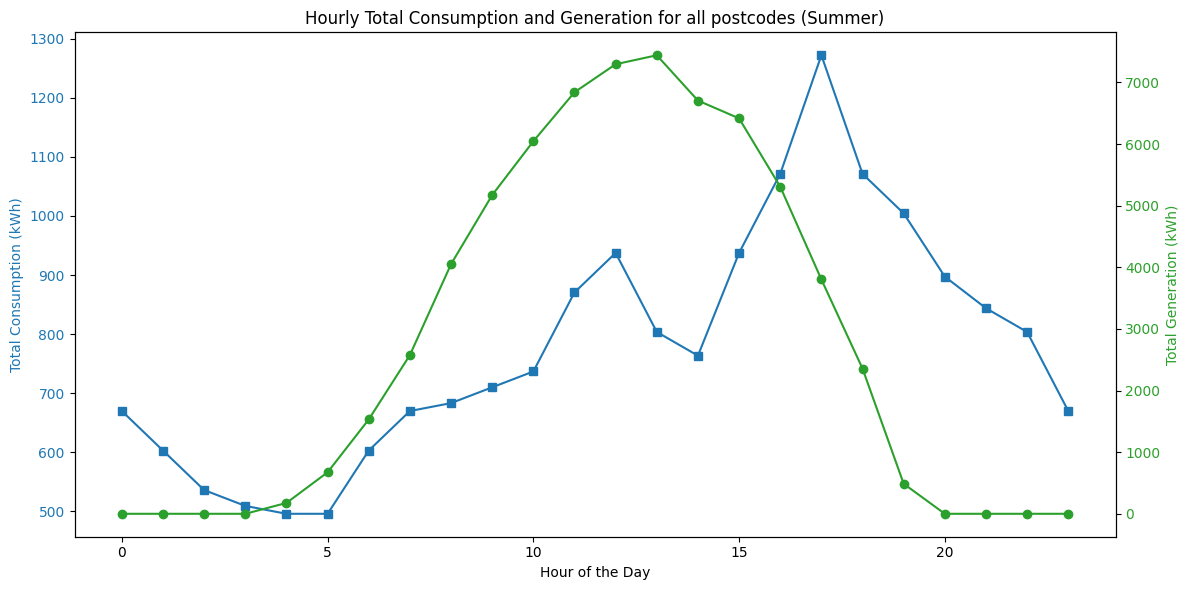

In [5]:
totals = postcode_aggregated.groupby("hour").agg({
    "total_consumption":"sum",
    "total_generation":"sum"
}).reset_index()
totals['Difference'] = totals['total_consumption'] - totals['total_generation']

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Total Consumption (kWh)', color='tab:blue')
ax1.plot(totals['hour'], totals['total_consumption'], marker='s', color='tab:blue', label='Consumption')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Total Generation (kWh)', color='tab:green')
ax2.plot(totals['hour'], totals['total_generation'], marker='o', color='tab:green', label='Generation')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Hourly Total Consumption and Generation for all postcodes (Summer)')
fig.tight_layout()
plt.show()
